## Deep Learning, DL Models, and Applications

```python
# Skill Development Tasks
# Task 2: Empirical Diagnostic of Custom Weight Initializations and
# Gradient Vanishing
# ● Objective: Solve mathematical training instability in deep networks by analyzing activation
# distributions and gradient magnitudes under varying initialization distributions.
# ● Required Tech Stack: PyTorch (with Autograd explicitly disabled via
# requires_grad=False), NumPy, Matplotlib.
# ● Task Description: Students will design custom Xavier (Glorot) and Kaiming (He) weight
# initialization routines. They must write a tracking harness that hooks into an uninitialized
# 20-layer MLP to log and plot the mean and variance of intermediate activation vectors and
# weight gradients across epochs, demonstrating gradient vanishing or explosion.
```

In [38]:
#Step 1
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [39]:
#Step 2 Dataset
X = torch.randn(512,100)

Y = torch.randint(0,2,(512,))

In [40]:
#Step 3 Random Initialization
def random_init(in_dim,out_dim):

    return torch.randn(in_dim,out_dim)*0.1


In [41]:
#Step 5 Xavier Initialization
def xavier_init(in_dim,out_dim):

    std=np.sqrt(2/(in_dim+out_dim))

    return torch.randn(in_dim,out_dim)*std

In [42]:
#Step 6 Kaiming Initialization
def he_init(in_dim,out_dim):

    std=np.sqrt(2/in_dim)

    return torch.randn(in_dim,out_dim)*std

In [43]:
#Step 7 Create Network
layer_sizes=[100]+[256]*19+[2]

In [44]:
weights=[]

for i in range(len(layer_sizes)-1):

    W=he_init(layer_sizes[i],layer_sizes[i+1])

    weights.append(W)

In [45]:
#Step 8 Forward Pass
def relu(x):

    return torch.maximum(x,torch.tensor(0.0))

In [46]:
activations=[]

A=X

for W in weights:

    A=A@W

    A=relu(A)

    activations.append(A)

In [47]:
#Step 9 Record Activation Statistics
means=[]

variances=[]

for A in activations:

    means.append(A.mean().item())

    variances.append(A.var().item())

In [48]:
#Step 10 Manual Gradient Tracking
grad=torch.ones_like(activations[-1])

gradient_norms=[]

for i in reversed(range(len(weights))):

    gradient_norms.append(
        grad.abs().mean().item()
    )

    grad = grad @ weights[i].T

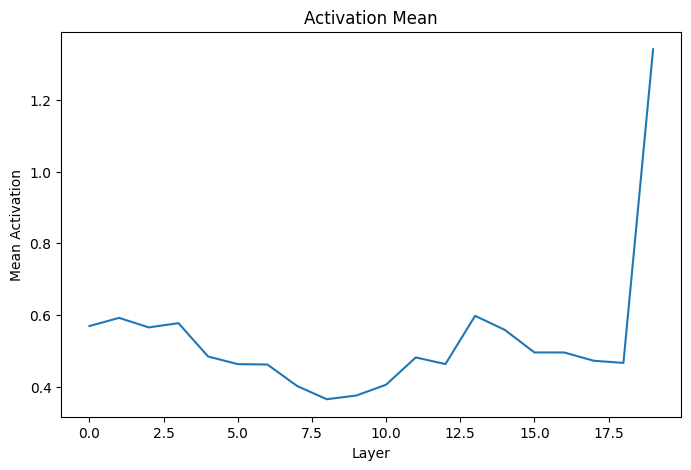

In [49]:
#Step 11 Plot Activation Mean
plt.figure(figsize=(8,5))

plt.plot(means)

plt.xlabel("Layer")

plt.ylabel("Mean Activation")

plt.title("Activation Mean")

plt.show()

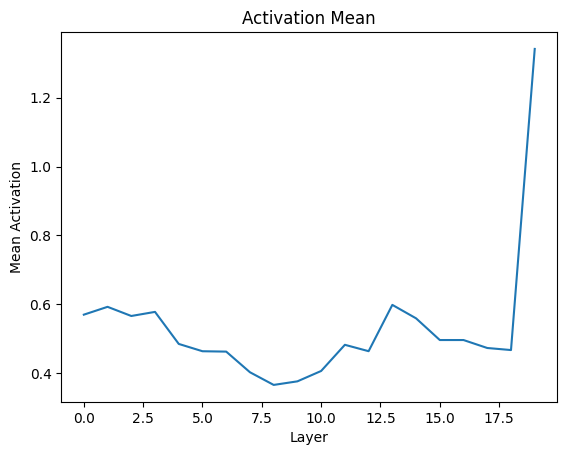

In [50]:
#plt.figure(figsize=(8,5))

plt.plot(means)

plt.xlabel("Layer")

plt.ylabel("Mean Activation")

plt.title("Activation Mean")

plt.show()


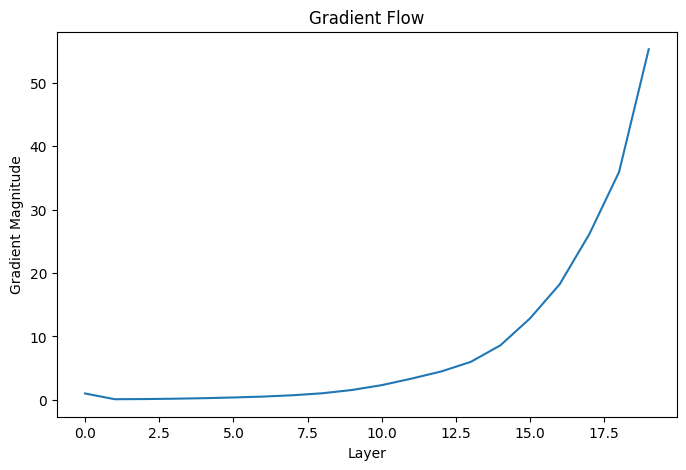

In [51]:
#Step 13 Plot Gradient Magnitude
plt.figure(figsize=(8,5))

plt.plot(gradient_norms)

plt.xlabel("Layer")

plt.ylabel("Gradient Magnitude")

plt.title("Gradient Flow")

plt.show()

In [52]:
#Step 14: Compare All Initializations
def run_experiment(init_function):

    # Network Architecture
    layer_sizes = [100] + [256]*19 + [2]

    # Initialize Weights
    weights = []

    for i in range(len(layer_sizes)-1):
        W = init_function(layer_sizes[i], layer_sizes[i+1])
        weights.append(W)

    # Forward Pass
    A = X

    activations = []

    for W in weights:
        A = A @ W
        A = relu(A)
        activations.append(A)

    # Activation Statistics
    activation_means = []
    activation_variances = []

    for A in activations:
        activation_means.append(A.mean().item())
        activation_variances.append(A.var().item())

    # Gradient Tracking
    grad = torch.ones_like(activations[-1])

    gradient_means = []
    gradient_variances = []

    for i in reversed(range(len(weights))):

        gradient_means.append(grad.mean().item())
        gradient_variances.append(grad.var().item())

        grad = grad @ weights[i].T

    gradient_means.reverse()
    gradient_variances.reverse()

    return activation_means, activation_variances, gradient_means, gradient_variances

In [55]:
random_mean, random_var, random_gmean, random_gvar = run_experiment(random_init)
xavier_mean, xavier_var, xavier_gmean, xavier_gvar = run_experiment(xavier_init)
he_mean, he_var, he_gmean, he_gvar = run_experiment(he_init)

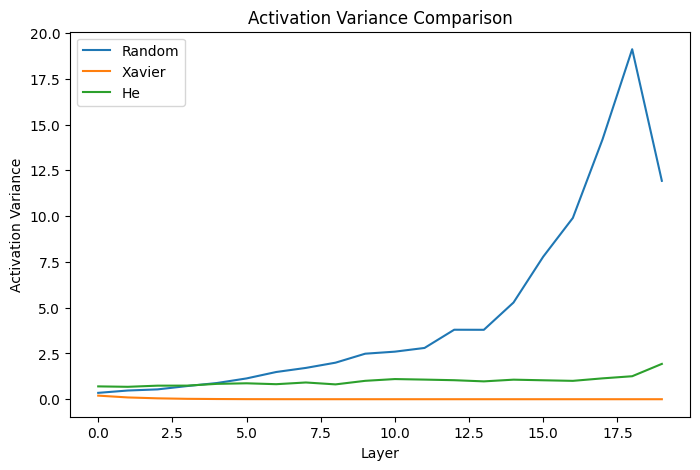

In [56]:
plt.figure(figsize=(8,5))

plt.plot(random_var, label="Random")
plt.plot(xavier_var, label="Xavier")
plt.plot(he_var, label="He")

plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("Activation Variance Comparison")

plt.legend()
plt.show()